### **Optimizadores, schedules de tasa de aprendizaje y ajuste de hiperparámetros**

Los temas que trabaja el código para este cuaderno son:

- Entrenamiento base con **SGD**
- *Schedulers* de tasa de aprendizaje: **ExponentialLR, StepLR, CosineAnnealingLR y ReduceLROnPlateau**
- Comparación entre **SGD, momentum, Nesterov y AdamW**
- **Gradient clipping**

#### **Idea general**
Primero se entrena una red totalmente conectada sobre **FashionMNIST**.  
Luego se comparan distintas estrategias de optimización y ajuste de la tasa de aprendizaje.  
Al final, se muestra cómo automatizar la búsqueda de hiperparámetros.

#### **0. Preparación del entorno**

En esta parte se importan librerías, se configura la visualización y se fija la semilla para reproducibilidad.

In [1]:
# Importaciones principales para PyTorch, visualización y utilidades del cuaderno.
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision 
from torchvision import transforms

from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

import pandas as pd

from sklearn.metrics import accuracy_score

import time

from utils import train_simple_network, Flatten, weight_reset, set_seed, run_epoch

In [2]:
# Configuración de visualización dentro del notebook.
%matplotlib inline

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('png', 'pdf')
except Exception:
    pass

In [3]:
# Fijamos semillas y opciones deterministas para mejorar la reproducibilidad.
torch.backends.cudnn.deterministic=False
set_seed(45)

In [4]:
# Seleccionamos GPU si está disponible, en caso contrario usamos CPU.
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

#### **1. Función de entrenamiento**

La siguiente función concentra la lógica principal del cuaderno: entrenamiento por épocas, evaluación en validación/prueba y registro de métricas.

In [5]:
# Función general de entrenamiento y evaluación.
# Recibe el modelo, la pérdida, los dataloaders, el optimizador y, opcionalmente un scheduler de tasa de aprendizaje.
def train_network(model, loss_func, train_loader, val_loader=None, test_loader=None, score_funcs=None, 
                  epochs=50, device="cpu", checkpoint_file=None, 
                  lr_schedule=None, optimizer=None, disable_tqdm=False):
    """Entrena redes neuronales simples.

    Argumentos con nombre:
    model -- modelo de PyTorch/"Module" a entrenar
    loss_func -- función de pérdida que recibe las salidas del modelo y las etiquetas
    train_loader -- objeto DataLoader de PyTorch con pares (entrada, etiqueta)
    val_loader -- DataLoader opcional para evaluar después de cada época
    test_loader -- DataLoader opcional para evaluar después de cada época
    score_funcs -- diccionario de funciones de evaluación para medir el rendimiento del modelo
    epochs -- número de épocas de entrenamiento a realizar
    device -- dispositivo de cómputo donde se realizará el entrenamiento
    lr_schedule -- scheduler de tasa de aprendizaje usado para modificar η mientras el modelo entrena
    optimizer -- método usado para actualizar los gradientes durante el aprendizaje
    """
    if score_funcs is None:
        score_funcs = {}

    to_track = ["epoch", "total time", "train loss"]
    if val_loader is not None:
        to_track.append("val loss")
    if test_loader is not None:
        to_track.append("test loss")

    for eval_score in score_funcs:
        to_track.append("train " + eval_score)
        if val_loader is not None:
            to_track.append("val " + eval_score)
        if test_loader is not None:
            to_track.append("test " + eval_score)

    total_train_time = 0
    results = {item: [] for item in to_track}

    if optimizer is None:
        optimizer = torch.optim.AdamW(model.parameters())

    model.to(device)

    for epoch in tqdm(range(epochs), desc="Epoch", disable=disable_tqdm):
        model.train()

        total_train_time += run_epoch(
            model, optimizer, train_loader, loss_func, device,
            results, score_funcs, prefix="train", desc="Training",
            disable_tqdm=disable_tqdm
        )

        results["epoch"].append(epoch)
        results["total time"].append(total_train_time)

        if val_loader is not None:
            model.eval()
            with torch.no_grad():
                run_epoch(
                    model, optimizer, val_loader, loss_func, device,
                    results, score_funcs, prefix="val", desc="Validating",
                    disable_tqdm=disable_tqdm
                )

        if lr_schedule is not None:
            if isinstance(lr_schedule, torch.optim.lr_scheduler.ReduceLROnPlateau):
                if val_loader is None:
                    raise ValueError("ReduceLROnPlateau requiere val_loader para usar 'val loss'.")
                lr_schedule.step(results["val loss"][-1])
            else:
                lr_schedule.step()

        if test_loader is not None:
            model.eval()
            with torch.no_grad():
                run_epoch(
                    model, optimizer, test_loader, loss_func, device,
                    results, score_funcs, prefix="test", desc="Testing",
                    disable_tqdm=disable_tqdm
                )

        if checkpoint_file is not None:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'results': results
            }, checkpoint_file)

    return pd.DataFrame.from_dict(results)


#### **2. Datos y modelo base**

Usaremos **FashionMNIST** y una red **MLP** sencilla como modelo de referencia.

In [6]:
# Cargamos FashionMNIST y definimos los dataloaders de entrenamiento y prueba.
epochs = 50 
B = 256
train_data = torchvision.datasets.FashionMNIST("./data", train=True, transform=transforms.ToTensor(), download=True)
test_data = torchvision.datasets.FashionMNIST("./data", train=False, transform=transforms.ToTensor(), download=True)

train_loader = DataLoader(train_data, batch_size=B, shuffle=True)
test_loader = DataLoader(test_data, batch_size=B)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26421880/26421880 [00:16<00:00, 1563652.23it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29515/29515 [00:00<00:00, 148343.33it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4422102/4422102 [00:02<00:00, 1640676.99it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5148/5148 [00:00<00:00, 5067420.09it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



In [7]:
# Definimos la arquitectura base totalmente conectada (MLP) que servirá para comparar optimizadores y schedulers.
# ¿Cuántos valores tiene la entrada? Esto ayuda a definir el tamaño de las capas siguientes.
D = 28*28 # Imágenes de 28 x 28
# Tamaño de la capa oculta
n = 128 
# ¿Cuántos canales tiene la entrada?
C = 1
# ¿Cuántas clases hay?
classes = 10

fc_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n),
    nn.Tanh(),
    nn.Linear(n,  n),
    nn.Tanh(),
    nn.Linear(n,  n),
    nn.Tanh(),
    nn.Linear(n, classes),
)

In [8]:
# Tasa de aprendizaje inicial de referencia.
eta_0 = 0.1

#### **3. Línea base con SGD**

Primero entrenamos el modelo con **SGD estándar** para tener un punto de comparación.

In [9]:
# Entrenamiento base con SGD sin trucos adicionales.
# Este resultado servirá como línea base para las comparaciones posteriores.
loss_func = nn.CrossEntropyLoss()

#Usando la nueva función `train_network` de una manera equivalente a como podríamos haberlo hecho anteriormente.
fc_results = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=torch.optim.SGD(fc_model.parameters(), lr=eta_0), score_funcs={'Accuracy': accuracy_score}, device=device,disable_tqdm=True)

<Axes: xlabel='epoch', ylabel='test Accuracy'>

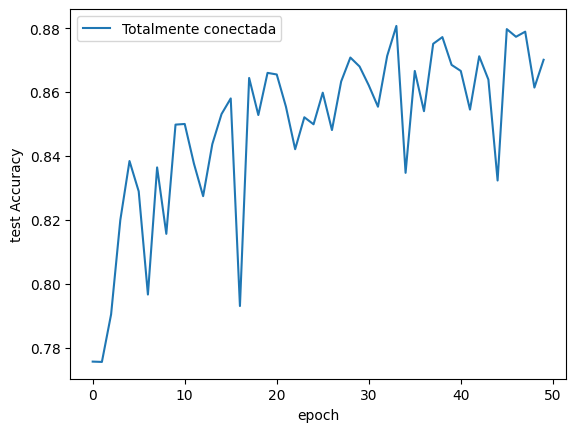

In [10]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Totalmente conectada')

#### **4. Schedulers de tasa de aprendizaje**

Ahora se estudia cómo cambia el entrenamiento cuando modificamos la tasa de aprendizaje a lo largo de las épocas.

Text(0, 0.5, 'Tasa de aprendizaje')

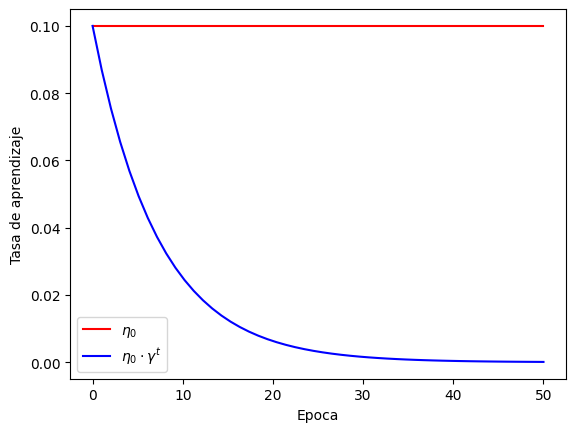

In [11]:
# Visualización conceptual de un decaimiento exponencial de la tasa de aprendizaje.
T = 50  
epochs_input = np.linspace(0, 50, num=50)  
eta_init = eta_0
eta_min = 0.0001
gamma = np.power(eta_min / eta_init, 1.0 / T)

effective_learning_rate = eta_init * np.power(gamma, epochs_input)

sns.lineplot(x=epochs_input, y=eta_init, color='red', label=r"$\eta_0$")
ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label=r"$\eta_0 \cdot \gamma^t$")
ax.set_xlabel('Epoca')
ax.set_ylabel('Tasa de aprendizaje')


In [12]:
# Entrenamiento con scheduler exponencial (ExponentialLR) sobre SGD.
fc_model.apply(weight_reset) # Volvemos a inicializar los pesos para reutilizar el mismo modelo

eta_min = 0.0001 # Tasa de aprendizaje final deseada 

gamma_expo = (eta_min/eta_0)**(1/epochs) 

optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0) # Configuramos el optimizador
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma_expo)
# Entrenamos de manera usual, pero ahora pasando optimizador y scheduler
fc_results_expolr = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=optimizer, lr_schedule=scheduler, score_funcs={'Accuracy': accuracy_score}, device=device,  disable_tqdm=True)

Text(0, 0.5, 'Tasa de aprendizaje')

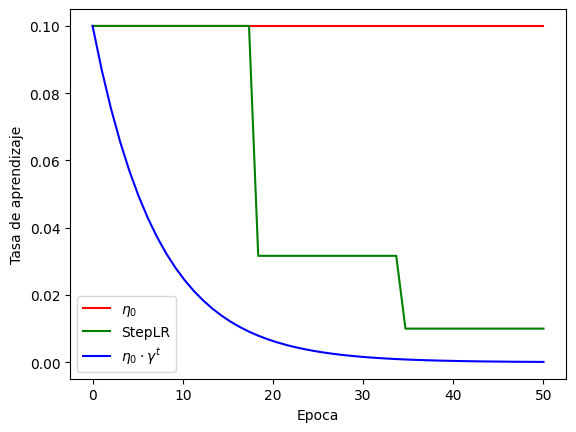

In [13]:
sns.lineplot(x=epochs_input, y=eta_init, color='red', label=r"$\eta_0$")
sns.lineplot(x=epochs_input, y=[eta_init]*18+[eta_init/3.16]*16+[eta_init/10]*16, color='green', label="StepLR")
ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label=r"$\eta_0 \cdot \gamma^t$")
ax.set_xlabel('Epoca')
ax.set_ylabel('Tasa de aprendizaje')

In [14]:
# Entrenamiento con StepLR: la tasa de aprendizaje baja en escalones durante el entrenamiento.
fc_model.apply(weight_reset)

optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, epochs//4, gamma=0.3) 

fc_results_steplr = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=optimizer, lr_schedule=scheduler, score_funcs={'Accuracy': accuracy_score}, device=device,  disable_tqdm=True)

Text(0, 0.5, 'Tasa de aprendizaje')

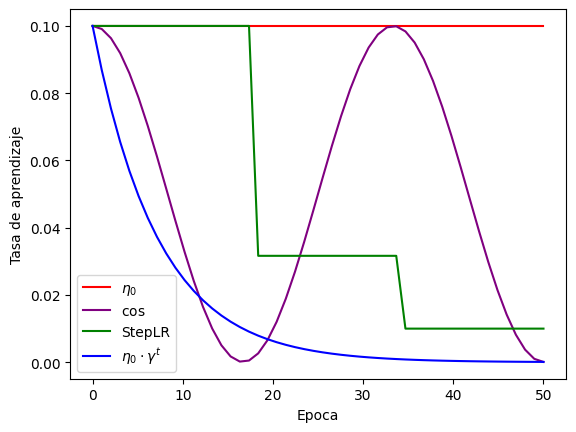

In [15]:
cos_lr = eta_min + 0.5*(eta_init-eta_min)*(1+np.cos(epochs_input/(T/3.0)*np.pi))

sns.lineplot(x=epochs_input, y=eta_init, color='red', label=r"$\eta_0$")
sns.lineplot(x=epochs_input, y=cos_lr, color='purple', label=r"$\cos$")
sns.lineplot(x=epochs_input, y=[eta_init]*18+[eta_init/3.16]*16+[eta_init/10]*16, color='green', label="StepLR")
ax = sns.lineplot(x=epochs_input, y=effective_learning_rate, color='blue', label=r"$\eta_0 \cdot \gamma^t$")
ax.set_xlabel('Epoca')
ax.set_ylabel('Tasa de aprendizaje')

In [16]:
# Entrenamiento con CosineAnnealingLR para variar la tasa de aprendizaje con una curva coseno.
fc_model.apply(weight_reset)

optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0)
# Hacemos que la curva coseno complete varias fases durante el entrenamiento
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs//3, eta_min=0.0001)
fc_results_coslr = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=optimizer, lr_schedule=scheduler, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)

<Axes: xlabel='epoch', ylabel='test loss'>

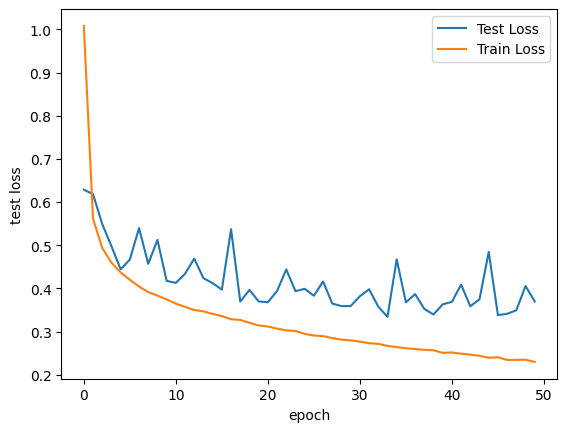

In [17]:
# Comparación simple entre pérdida de entrenamiento y pérdida de prueba para la línea base.
sns.lineplot(x='epoch', y='test loss', data=fc_results, label='Test Loss')
sns.lineplot(x='epoch', y='train loss', data=fc_results, label='Train Loss')

In [18]:
# Separamos una parte del conjunto de entrenamiento para validación.
# Aquí usamos ReduceLROnPlateau, que ajusta el learning rate cuando la métrica se estanca.
fc_model.apply(weight_reset)  # Reiniciamos los pesos para no redefinir el modelo

# Creamos subconjuntos de entrenamiento y validación, ya que no tenemos uno explícito.
# Fijamos un generador para hacer reproducible la partición.
split_generator = torch.Generator().manual_seed(45)
train_sub_set, val_sub_set = torch.utils.data.random_split(
    train_data,
    [int(len(train_data) * 0.8), int(len(train_data) * 0.2)],
    generator=split_generator
)

# Creamos dataloaders para entrenamiento y validación.
train_sub_loader = DataLoader(train_sub_set, batch_size=B, shuffle=True)
val_sub_loader = DataLoader(val_sub_set, batch_size=B)
# El test_loader se mantiene intacto, no conviene ajustar decisiones mirando el test.

optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=10
)  # Reduce la tasa de aprendizaje cuando la validación deja de mejorar

# Entrenamos usando SOLO el subconjunto de entrenamiento.
fc_results_plateau = train_network(
    fc_model,
    loss_func,
    train_sub_loader,
    val_loader=val_sub_loader,
    test_loader=test_loader,
    epochs=epochs,
    optimizer=optimizer,
    lr_schedule=scheduler,
    score_funcs={'Accuracy': accuracy_score},
    device=device,
    disable_tqdm=True
)


<Axes: xlabel='epoch', ylabel='test Accuracy'>

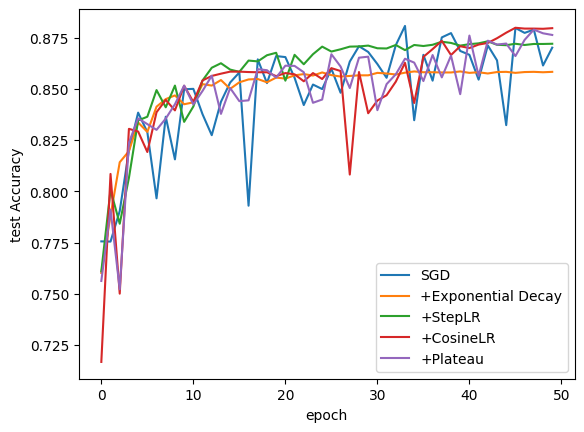

In [19]:
# Comparación de accuracy entre varios schedulers de la tasa de aprendizaje
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='SGD')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_expolr, label='+Exponential Decay')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_steplr, label='+StepLR')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_coslr, label='+CosineLR')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_plateau, label='+Plateau')

#### **5. Momentum, Nesterov y AdamW**

En esta sección se comparan optimizadores más fuertes que SGD puro.

In [20]:
# Entrenamiento con SGD + momentum.
fc_model.apply(weight_reset)

optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0, momentum=0.9, nesterov=False)

fc_results_momentum = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=optimizer, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)

In [21]:
# Entrenamiento con SGD + momentum de Nesterov.
fc_model.apply(weight_reset)

optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0, momentum=0.9, nesterov=True)

fc_results_nesterov = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=optimizer, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)

<Axes: xlabel='epoch', ylabel='test Accuracy'>

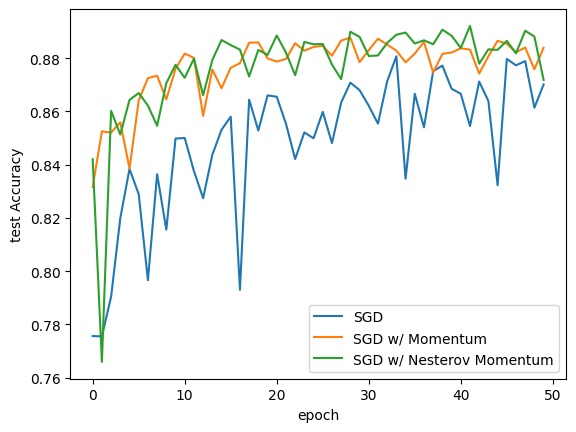

In [22]:
# Comparación entre SGD puro, SGD con momentum y SGD con Nesterov.
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='SGD')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_momentum, label='SGD w/ Momentum')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_nesterov, label='SGD w/ Nesterov Momentum')

In [23]:
# Entrenamiento con AdamW.
fc_model.apply(weight_reset)

# No fijamos manualmente la tasa de aprendizaje de AdamW porque su valor por defecto suele ser una buena base
# Además, AdamW puede ser sensible a cambios grandes en la tasa de aprendizaje
optimizer = torch.optim.AdamW(fc_model.parameters())

fc_results_adam = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=epochs, optimizer=optimizer, score_funcs={'Accuracy': accuracy_score}, device=device,  disable_tqdm=True)

<Axes: xlabel='epoch', ylabel='test Accuracy'>

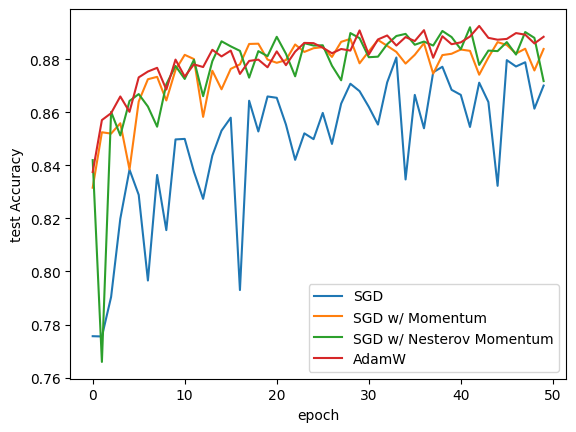

In [24]:
# Comparación entre SGD y AdamW.
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='SGD')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_momentum, label='SGD w/ Momentum')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_nesterov, label='SGD w/ Nesterov Momentum')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_adam, label='AdamW')

In [25]:
# AdamW con Cosine Annealing
fc_model.apply(weight_reset)
optimizer = torch.optim.AdamW(fc_model.parameters())

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs//3)
fc_results_adam_coslr = train_network(
    fc_model,
    loss_func,
    train_loader,
    test_loader=test_loader,
    epochs=epochs,
    optimizer=optimizer,
    lr_schedule=scheduler,
    score_funcs={'Accuracy': accuracy_score},
    device=device,
    disable_tqdm=True
)

# SGD + Nesterov con Cosine Annealing
fc_model.apply(weight_reset)
optimizer = torch.optim.SGD(fc_model.parameters(), lr=eta_0, momentum=0.9, nesterov=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs//3)
fc_results_nesterov_coslr = train_network(
    fc_model,
    loss_func,
    train_loader,
    test_loader=test_loader,
    epochs=epochs,
    optimizer=optimizer,
    lr_schedule=scheduler,
    score_funcs={'Accuracy': accuracy_score},
    device=device,
    disable_tqdm=True
)

<Axes: xlabel='epoch', ylabel='test Accuracy'>

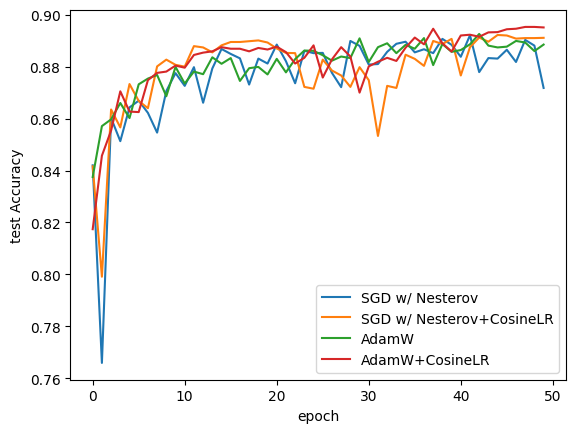

In [26]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_nesterov, label='SGD w/ Nesterov')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_nesterov_coslr, label='SGD w/ Nesterov+CosineLR')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_adam, label='AdamW')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_adam_coslr, label='AdamW+CosineLR')

#### **6. Gradient clipping**

Aquí se limita la magnitud de los gradientes para estabilizar el entrenamiento.

In [27]:
# Aplicamos gradient clipping para limitar la magnitud de los gradientes.
# Esto ayuda a estabilizar el entrenamiento cuando aparecen gradientes muy grandes.
fc_model.apply(weight_reset)

for p in fc_model.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -5, 5))

optimizer = torch.optim.AdamW(fc_model.parameters())
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs//3)
fc_results_adam_coslr_clamp = train_network(
    fc_model,
    loss_func,
    train_loader,
    test_loader=test_loader,
    epochs=epochs,
    optimizer=optimizer,
    lr_schedule=scheduler,
    score_funcs={'Accuracy': accuracy_score},
    device=device,
    disable_tqdm=True
)


<Axes: xlabel='epoch', ylabel='test Accuracy'>

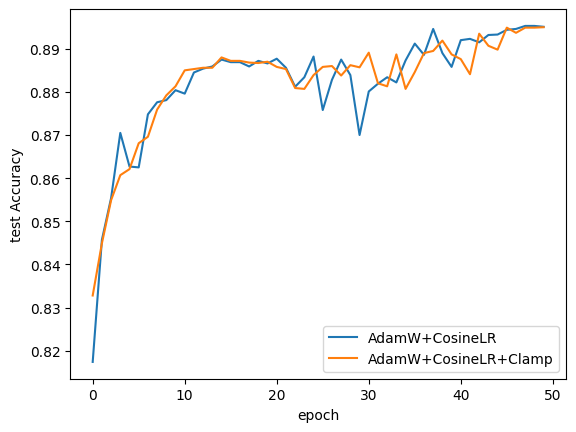

In [28]:
# Efecto del gradient clipping sobre la accuracy final.
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_adam_coslr, label='AdamW+CosineLR')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results_adam_coslr_clamp, label='AdamW+CosineLR+Clamp')


### **Ejercicios**
#### **1. Comparar SGD, Momentum y Adam**

Entrena la misma red neuronal pequeña sobre el mismo dataset usando:

* **SGD**
* **SGD con momentum**
* **Adam**

Qué debes analizar:

* Pérdida de entrenamiento por época
* Accuracy final
* Velocidad de convergencia.

Pregunta:

* ¿Qué optimizador aprende más rápido?
* ¿Cuál es más estable?

#### **2. Efecto de `weight decay` como regularización L2**

Entrena el mismo modelo varias veces cambiando solo `weight_decay`:

* `0.0`
* `1e-4`
* `1e-3`
* `1e-2`

Qué debes observar:

* Pérdida de entrenamiento
* Pérdida de validación
* Diferencia entre entrenamiento y validación.

Pregunta:

* ¿En qué caso aparece menos sobreajuste?
* ¿Qué pasa si el `weight_decay` es demasiado alto?

#### **3. Probar dropout en distintas intensidades**

Agrega una capa `Dropout` a una red conectada completamente y prueba:

* `p = 0.0`
* `p = 0.2`
* `p = 0.5`

Qué debes analizar:

* Comportamiento del entrenamiento
* Rendimiento en validación
* Si el modelo se vuelve más robusto o demasiado inestable.

Pregunta:

* ¿Cuál valor de dropout parece balancear mejor aprendizaje y generalización?

#### **4. Comparar una red con y sin Batch Normalization**

Construye dos modelos:

* Modelo A: sin BatchNorm
* Modelo B: con BatchNorm

Usa el mismo optimizador y mismas épocas.

Qué debes medir:

* Rapidez de convergencia
* Estabilidad de la pérdida
* Accuracy final.

Pregunta:

* ¿BatchNorm ayuda a entrenar más rápido?
* ¿La curva de pérdida se vuelve más suave?.

#### **5. Implementar early stopping con validación**

Entrena una red por muchas épocas, pero detén el entrenamiento si la pérdida de validación no mejora después de cierto número de épocas, por ejemplo `patience = 5`.

Qué debes registrar:

* Época en la que se detuvo
* Mejor pérdida de validación
* Accuracy final del mejor modelo.

Pregunta:

* ¿Early stopping evita sobreentrenar?
* ¿Qué diferencia hay entre el último modelo y el mejor modelo guardado?.

#### **6. Comparar Adam vs AdamW**

Entrena el mismo modelo con:

* **Adam**
* **AdamW**

Mantén iguales:

* Tasa de aprendizaje
* Número de épocas
* Arquitectura
* Dataset

Qué debes analizar:

* Pérdida de validación
* Accuracy
* Efecto de la regularización.

Pregunta:

* ¿Qué diferencia práctica ves entre Adam y AdamW?
* ¿AdamW generaliza mejor en tu experimento?.


#### **Entrega final recomendada**

Para cada ejercicio, entrega:

* Una breve hipótesis
* El código
* Una gráfica de pérdida
* Una tabla con resultados
* Una conclusión de 3 a 5 líneas.



In [ ]:
## Tus respuestas